![](https://www.dii.uchile.cl/wp-content/uploads/2021/06/Magi%CC%81ster-en-Ciencia-de-Datos.png)

**MDS7202: Laboratorio de Programación Científica para Ciencia de Datos**

### 👨‍🏫👩‍🏫 Cuerpo Docente:

- Profesor: Pablo Badilla, Diego Cortez
- Auxiliar: Melanie Peña Torres, Valentina Rojas Osorio
- Ayudante: Javiera Arévalo, Tamara Carrasco, Ignacio Reyes

### 👨‍💻👩‍💻 Estudiantes:
- Estudiante n°1: Patricio Espinoza Acuña.
- Estudiante n°2: Javiera Romero Orrego.

_Por favor, lean detalladamente las instrucciones de la tarea antes de empezar a escribir._

---

## Reglas

El proyecto consta de 3 partes: **Informe de Análisis** (30%), **Construcción del Modelo** (40%) y **Despliegue del Modelo** (30%). Este notebook corresponde a la **Parte 2 - Construcción del Modelo**, y asume que ya completaste la **Parte 1 - Informe de Análisis**.

### **Requisitos del proyecto**
- **Grupos**: Formar equipos de **2 personas**.
- **Plazo de entrega**: Hasta el Viernes 10 de Julio
- **Consultas**: Cualquier duda fuera del horario de clases debe ser planteada en el foro correspondiente. Los mensajes enviados al equipo docente serán respondidos únicamente por este medio. Por favor, revisen las respuestas anteriores en el foro antes de realizar nuevas consultas.
- **Plagio**: La copia o reutilización no autorizada de trabajos de otros grupos está **estrictamente prohibida**. El incumplimiento de esta norma implicará la anulación inmediata del proyecto y una posible sanción académica.
- **Material permitido**: Pueden usar cualquier material del curso, ya sea notas, lecturas, códigos, o referencias proporcionadas por los docentes, que consideren útil para el desarrollo del proyecto.

---

## 📊 Distribución de Puntaje

La nota va de **1.0 a 7.0** (escala chilena): **1.0 de base + 6.0 puntos** repartidos como se muestra. Solo se evalúa **lo que implementas y respondes**; el **código y los recursos entregados no tienen puntaje**.

| Sección | Qué se evalúa | Puntaje |
|---|---|---:|
| **1 — Preparación** | 5 preguntas conceptuales (0.1 c/u) | 0.5 |
| **2 — Introducción a la Experimentación** | 3 preguntas (0.2 c/u) | 0.6 |
| **3 — Barrido de Combinaciones** | 10 experimentos (0.2 c/u) = 2.0 · preguntas LogReg 0.9 · Árbol/RF 0.2 · LightGBM 0.4 · MLP 0.4 | 3.9 |
| **4 — Selección del Mejor Modelo** | 5 preguntas (0.2 c/u) | 1.0 |
| | **Total puntos** | **6.0** |
| | **+ Base** | **1.0** |
| | **Nota máxima** | **7.0** |

> El puntaje de cada pregunta y experimento aparece **inline** como `(0.X pts)`.

Esta nota corresponde a la nota de la **Parte 2** que equivale a un **40%** de la nota del proyecto final. Para obtener la nota final, las notas individuales de cada parte se ponderan de la siguiente manera.

| Parte              | Ponderación |
|--------------------|------------:|
| 1 — Análisis       | 30%         |
| **2 — Modelo**     | **40%**     |
| 3 — Despliegue     | 30%         |


## 📖 Introducción

<p align="center">
    <img src="./chaucherapp.jpg" alt="Alt Text" width="700">
</p>

La app chilena **ChaucherApp** ha emergido recientemente como una de las nuevas apps *FinTech* que apuesta por dominar en un competitivo mercado. Esta app ofrece una billetera digital que permite hacer transferencias, tarjetas digitales que permiten comprar, y servicios financieros como préstamos, seguros e inversiones.

Sin duda es sorprendente que **ChaucherApp** sea uno de los líderes de la industria fintech, siendo una empresa tan joven. En las palabras del CEO de la empresa, el Sr. Querty _'El gran éxito de ChaucherApp se debe a que entendimos la importancia de escuchar y responder eficientemente al cliente'_. En efecto, **ChaucherApp** fue diseñada desde el comienzo con una robusta arquitectura digital relacionada al **Soporte al cliente**.

Durante años, **ChaucherApp** ha logrado dar respuesta satisfactoria a cientos de tickets de soporte al cliente al mes, lo que le ha permitido inspirar confianza y prestigio. Por supuesto, esto también ha generado una gran cantidad de datos que pueden ser útiles para las siguientes etapas de crecimiento de la empresa. Y es que, a medida que el mercado se hace más competitivo, se hace más necesario aumentar la eficiencia de los procesos de respuesta de tickets, por lo que el Sr. Querty ha optado por **automatizar el proceso** incorporando inteligencia artificial.

Luego de intensa planificación ejecutiva y jornadas de analítica, han decidido que el primer paso para automatizar será el de desarrollar un modelo de **priorización de tickets** de soporte al cliente utilizando **modelos de lenguaje** y **aprendizaje de máquinas**. De esta manera podrán optimizar recursos humanos mientras se desarrollan otras herramientas.

Para lograr esta tarea, te han encargado analizar datos históricos de tickets de soporte al cliente que ya han sido manualmente priorizados, presentes en el archivo `data/tickets.parquet`. En él, encontrarás tickets con el contenido del ticket, categoría, canal, fecha y priorización, que puede ser `Baja`, `Media`, `Alta` o `Crítica`. Tu objetivo es utilizar esa data y los medios, algoritmos y estrategias que estimes convenientes para construir un **modelo clasificador** que sea capaz de predecir esta categoría en base al texto y atributos del ticket.

Con esta información, tus tareas a realizar son primero **analizar y entender los datos**, luego **construir un modelo de inferencia**, y finalmente **implementar ese modelo** para que el equipo de ejecutivos de ChaucherApp pueda utilizarlo.

---

# Parte 2 - Construcción del Modelo

En la Parte 1 entendiste el problema y exploraste los datos. Recapitulemos lo que ya sabemos y que guiará todo este notebook:

- El problema es de **clasificación multiclase**: predecir `Nivel_Prioridad` ∈ {`Baja`, `Media`, `Alta`, `Critica`}.
- Las clases están **desbalanceadas** (Media ~39%, Baja ~36%, Alta ~17%, Critica ~7%).
- La variable `Tiempo_de_Resolución_Horas` es **data leakage** (no está disponible en inferencia), así que **no la usaremos**.
- Contamos con features de **texto** (`Asunto_Ticket`, `Contenido_Ticket`), **categóricas** (`Canal_Ticket`, `Categoría_Problema`), una **numérica** (`N_Caracteres_Ticket`) y los **embeddings** (`gemini-embedding-001`, 1024 dimensiones).
- Siguiendo la decisión de la Parte 1, la **métrica a optimizar será el _macro recall_** (promedio simple del recall por clase), para no descuidar a la clase `Critica`.

La idea de esta parte es experimentar con muchas combinaciones de **(features × modelo)**, optimizando los hiperparámetros con **Optuna** y registrando todo en **MLflow**, para finalmente elegir y exportar el mejor.

> **MLflow**: usaremos MLflow para *experiment tracking*. Como MLflow 3.x deprecó el backend de archivos, usaremos un backend de base de datos local (`sqlite:///mlflow.db`). Si no lo tienes instalado:
> ```bash
> uv pip install "mlflow>=3.14" ipywidgets optuna scikit-learn "pandas<3" optuna_integration lightgbm nltk
> ```
> Para abrir la interfaz gráfica y comparar tus runs:
> ```bash
> mlflow ui --backend-store-uri sqlite:///mlflow.db
> ```

---

# Sección 1 - Preparación — (0.5 pts)

Antes de modelar, dejaremos listo el **protocolo experimental**: definir el split y la métrica y el ejecutor de experimentos antes de ejecutar cualquier experimento.

> Este código será dado, por ende, no tendrá puntaje.

Tareas de esta sección:

1. Importar librerías, configurar MLflow (tracking URI + experimento)., fijar semillas y definir las **constantes compartidas**.
2. Cargar `tickets.parquet` y `embeddings.parquet`. Descartar el *data leakage*, contruir una única columna de texto y armar un **único** dataframe `X_full` que contenga las features tabulares, el texto y las 1024 columnas de embedding.
3. Separar en **train / val / test (60/20/20) estratificado**.

In [ ]:
# ------------ 1. Importar librerías, fijar semillas y configurar constantes ------------

import re

import joblib
import matplotlib.pyplot as plt
import mlflow
import numpy as np
import optuna
import pandas as pd
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split

optuna.logging.set_verbosity(optuna.logging.WARNING)
mlflow.set_tracking_uri("sqlite:///mlflow.db")

try:
    mlflow.create_experiment("ProyectoMDS7202")
except Exception:
    print("El experimento ya existe")
mlflow.set_experiment("ProyectoMDS7202")

# Definir constantes y fijar semillas
SEED = 42

np.random.seed(SEED)

ORDEN_CLASES = ["Baja", "Media", "Alta", "Critica"]
NUM_COLS = ["N_Caracteres_Ticket"]
CAT_COLS = ["Canal_Ticket", "Categoría_Problema"]
TEXT_COL = "Texto"

# ------------ 2. Cargar y preprocesar los datos ------------

# Cargar datos tabulares
df = pd.read_parquet("data/tickets.parquet")

# Descartamos la variable con data leakage detectada en la Parte 1
df = df.drop(columns=["Tiempo_de_Resolución_Horas"])

# Combinar campos de texto en una sola columna "Texto"
df["Texto"] = df["Asunto_Ticket"].fillna("") + " " + df["Contenido_Ticket"].fillna("")

# Cargar Embeddings (mismo orden de filas que df).
embeddings = pd.read_parquet("data/embeddings.parquet")
EMBEDDING_COLS = list(embeddings.columns)

# Generar único dataframe con todas las variables: tabular + texto + embeddings.
X_full = pd.merge(
    df.drop(columns=["Nivel_Prioridad", "Asunto_Ticket", "Contenido_Ticket"]),
    embeddings,
    on="Id_Ticket",
).drop(columns=["Id_Ticket"])
y = df["Nivel_Prioridad"]

print("---------- EDA Breve ----------\n")
print("X_full:", X_full.shape, "| columnas de embedding:", len(EMBEDDING_COLS))
print("Clases:", sorted(y.unique()))
display(X_full.head(10))
display(y.head(10))
display((y.value_counts() / len(y)).mul(100).round(2).rename("Distribución Labels (%)", inplace=True))

2026/07/10 03:33:32 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/07/10 03:33:32 INFO mlflow.store.db.utils: Updating database tables


---------- EDA Breve ----------

X_full: (2000, 1031) | columnas de embedding: 1024
Clases: ['Alta', 'Baja', 'Critica', 'Media']


,N_Caracteres_Ticket,Canal_Ticket,Categoría_Problema,Usuario-Tipo_de_Cuenta,Usuario-Antiguedad_Cuenta_Dias,Fecha_Envío,Texto,embedding_dim_1,embedding_dim_2,embedding_dim_3,...,embedding_dim_1015,embedding_dim_1016,embedding_dim_1017,embedding_dim_1018,embedding_dim_1019,embedding_dim_1020,embedding_dim_1021,embedding_dim_1022,embedding_dim_1023,embedding_dim_1024
0,531,Whatsapp,Cuenta,Premium,159,2024-01-02,Error al iniciar sesión en nuevo celular por d...,-0.011585,-0.008728,0.012878,...,-0.011539,-0.016249,0.004422,-0.022274,0.004511,0.001428,-0.007812,-0.020485,-0.001888,-0.000408
1,784,Whatsapp,Otro,Premium,192,2024-01-02,Error al actualizar correo electrónico: bloque...,0.014494,0.004070,0.011298,...,-0.019967,-0.008424,-0.002084,-0.002761,-0.004148,-0.007131,-0.012717,-0.019045,-0.015172,0.004308
2,600,Whatsapp,Fraude,Free,314,2024-01-02,Cobro desconocido en mi tarjeta digital Hola b...,-0.010936,0.020796,0.011680,...,-0.021763,-0.007094,-0.011453,-0.001084,-0.005820,-0.015085,0.003200,-0.019789,-0.018502,-0.001085
3,659,Whatsapp,Cuenta,Free,228,2024-01-02,"Cuenta bloqueada sin aviso, necesito ayuda urg...",0.003248,0.005420,0.003422,...,-0.019830,-0.007490,-0.013525,0.000086,-0.011983,0.007148,-0.002536,-0.016200,-0.003927,-0.004028
4,853,Whatsapp,Otro,Free,72,2024-01-03,Me descontaron plata del cajero y no salió el ...,-0.010437,0.013634,0.009859,...,-0.006401,-0.001971,0.002344,-0.010598,-0.011034,-0.012039,-0.000857,-0.009420,-0.006597,0.012463
5,672,Whatsapp,Otro,Free,71,2024-01-03,Problemas con retiro en cajero y saldo retenid...,-0.006699,0.015320,0.004916,...,-0.002004,-0.009383,0.002027,-0.004618,-0.005886,0.001436,-0.002760,-0.010959,-0.019190,0.013137
6,691,Correo,Cuenta,Free,27,2024-01-03,Problema con transferencia no recibida: dinero...,-0.001424,0.013316,-0.001574,...,-0.017849,0.000331,-0.004115,-0.007396,-0.016886,-0.004226,0.000309,-0.011096,-0.009890,0.001992
7,782,Whatsapp,Técnica,Free,193,2024-01-05,Error al acceder a la sección de inversiones (...,-0.001278,0.014927,0.002564,...,-0.021633,-0.006482,0.000185,-0.000037,-0.001324,-0.010792,0.003312,-0.020291,-0.002917,-0.004307
8,652,Página Web,Técnica,Free,283,2024-01-05,"Error en transferencia y saldo descontado, ayu...",0.003861,-0.008191,0.009408,...,-0.009119,-0.002006,0.003867,-0.010697,-0.020366,-0.003357,0.003855,-0.027547,-0.014218,0.010238
9,427,Whatsapp,Pregunta general,Free,72,2024-01-05,duda con inversiones y error en la app hola bu...,-0.010484,0.003417,0.022390,...,-0.016919,-0.004394,-0.004335,-0.009940,0.002788,-0.003919,0.001589,-0.023548,-0.008324,-0.010632


0     Baja
1    Media
2     Baja
3    Media
4    Media
5    Media
6    Media
7    Media
8    Media
9     Baja
Name: Nivel_Prioridad, dtype: object

Nivel_Prioridad
Media      39.45
Baja       36.15
Alta       17.50
Critica     6.90
Name: Distribución Labels (%), dtype: float64

In [4]:
# ------------ 3. Split train/val/test ------------

print("---------- Splits ----------\n")

X_train, X_tmp, y_train, y_tmp = train_test_split(
    X_full,
    y,
    test_size=0.4,
    stratify=y,
    random_state=SEED,
)
X_val, X_test, y_val, y_test = train_test_split(
    X_tmp,
    y_tmp,
    test_size=0.5,
    stratify=y_tmp,
    random_state=SEED,
)

print("Elementos por set | Train:", len(X_train), "| Val:", len(X_val), "| Test:", len(X_test))
d_y_train = (
    (y_train.value_counts() / len(y_train)).mul(100).round(2).rename("Distribución Labels Train (%)", inplace=True)
)
d_y_val = (y_val.value_counts() / len(y_val)).mul(100).round(2).rename("Distribución Labels Val (%)", inplace=True)
d_y_test = (y_test.value_counts() / len(y_test)).mul(100).round(2).rename("Distribución Labels Test (%)", inplace=True)
display(pd.concat([d_y_train, d_y_val, d_y_test], axis=1))

---------- Splits ----------

Elementos por set | Train: 1200 | Val: 400 | Test: 400


,Distribución Labels Train (%),Distribución Labels Val (%),Distribución Labels Test (%)
Nivel_Prioridad,,,
Media,39.00,38.75,41.50
Baja,36.67,37.50,33.25
Alta,16.92,17.25,19.50
Critica,7.42,6.50,5.75


Antes de modelar, responde:

1. ¿Por qué fijamos el split (train/val/test) **antes** de entrenar cualquier modelo? ¿Qué riesgo evitamos? **(0.1 pts)**
2. En general, siempre vamos a utilizar el enfoque de optimización de hiperparámetros. ¿Por qué utilizar train/val/test y no solo train/test es importante? ¿Qué otra técnica hay para evitar esto? **(0.1 pts)**
3. ¿Por qué usamos un split **estratificado**? ¿qué problema causaría un split aleatorio en val/test asumiendo que para esta cantidad de datos, la métricas pueden ser ruidosas? Apoya tu respuesta ejecutando el bloque `Split train/val/test` de la celda anterior comentando el parámetro `stratify` y justifica usando los resultados obtenidos. Luego, recuerda volver a agregar el parámetro, de lo contrario, tus resultados se podrían ver afectados. **(0.1 pts)**
4. ¿Por qué la métrica adecuada aquí es el **macro recall** y no, por ejemplo, el _accuracy_? Conéctalo con el desbalance y con lo que respondiste en la Parte 1. **(0.1 pts)**
5. ¿Qué es el **experiment tracking** y qué ganamos al registrar cada modelo en MLflow en lugar de solo imprimir métricas? Piensa en qué pasa si reinicias, por ejemplo, el notebook de Jupyter. **(0.1 pts)**

_Subtotal preguntas: 0.5 pts_

**Responde aquí**

1. Lo hacemos antes ya que si primero entrenaramos el modelo lo estaríamos ajustando a datos que luego vamos a ocupar en la evaluación, contaminando los resultados, y por tanto, no sería una evaluación fidedigna debido a que se generaría Data Leakage. Lo que estamos evitando en concreto es el riesgo de que el modelo haga overfitting a los datos de validación y evaluación mediante el ajuste de hiperparametros o decisiones de pre-procesamiento. 

2. De manera similar a lo que se mencionó anteriormente, si solo tuvieramos train/test e hicieramos optimización de hiperparámetros, nuevamente perdemos la "pureza" de nuestro conjunto de evaluación pues estaríamos ajustando los hiperparámetros a este conjunto, guiandose entonces con lo que se va a evaluar y quedando sesgado y sobreajustado a ellos, ocupamos el set de validación para poder hacer el ajuste y así solo utilizar test al final para la evaluación final. Otra técnica para evitar esto es usar la técnica de cross-validation, donde entrenamos en k-1 folds y evaluamos en el que queda, hacemos esto con varios folds cambiando el que actua como test, que evita que tengamos que reservar un pedazo de los datos para el ajuste y da una estimación buena al ir promediando sobre distintos folds. 

3. El split estratificado es usado ya que permite generar los conjuntos de entrenamiento, validación y test con distribuciones de clases similares a las originales, manteniendo así un comportamiento fidedigno al de los datos recopilados. Un split aleatorio en val/test puede ocurrir que las clases minoritarias como la crítica que representa solo el 7% no estén presentes en alguno de los conjuntos (también aplicable para la alta con un 17.5%). Dicha ausencia de dichas clases en validación generaría que los hiperparámetros que se ajusten no consideren este tipo de tickets, mientras que la ausencia de estas en test provocaría métricas ruidosas en las que se podría pensar que los modelos rindieron extremadamente bien, sin embargo, ocurrió que nunca tuvieron un caso de clase alta/crítica como para saber si el modelo lo predice correctamente o no.

Al utilizar el código anterior se puede ver que las distribuciones efectivamente cambian

Con stratify:
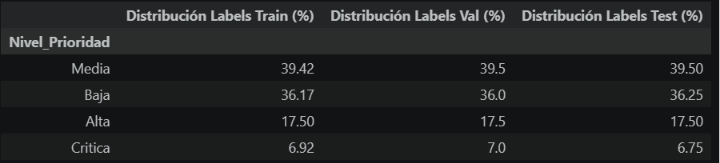

Sin stratify:
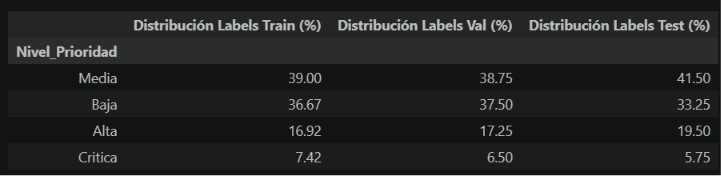

Se puede apreciar como la distribución de las clases por cada etapa varia notoriamente en cuanto a puntos porcentuales se refiere, mostrando que efectivamente en validación se afectaría a los hiperparámetros o métodos de pre-procesamiento seleccionados, así como también en test se obtendrían métricas no confiables.


4. El accuracy mide los aciertos sin diferenciar entre los niveles de urgencia de los tickets (clases), por lo que en el dataset actual, en donde hay un gran desbalance de clases, es muy probable que la mayoría de predicciones del modelo sean del tipo 'Baja' o 'Media', es decir, esta métrica tendrá un sesgo propio y proveniente del desbalance de los datos. Si uno utiliza el accuracy, puede que se obtenga facilmente sobre el 70 u 80% de esta métrica, sin embargo, para la accuracy puntual de las clases Alta y Crítica sea 0.

Por otra parte, la métrica adecuada es macro recall ya que realiza un calculo por clase del recall, de forma separada, y luego realiza un promedio simple, en el cual cada recall por clase pondera lo mismo. Esto significa que más fallos en las clases con menos ejemplos tendrán el mismo peso que aquellas predominante en el dataset. Por tanto, al optimizar esta métrica el modelo aprenderá a distinguir bien entre los distintos niveles de clases (urgencias de tickets)

5. El experiment tracking consiste en registrar cada tipo de experimeto que se hace de forma formal, se incluyen detalles acerca de que modelo se usa, los hiperparametros, features de input, metricas y tambien los artefactos resultantes como output. La ventaja de registrar cada uno en MLflow en vez de solo imprimair las métricas es que cada registro guardado es preservado más alla de la sesión, que es justamente lo que ocurriria con un jupyter notebook en donde una vez reiniciada, se deben correr nuevamente todas las celdas para tener las métricas o tener disponible el modelo entrenado. 

---

# Sección 2 - Introducción a la Experimentación — (0.6 pts)

La idea de la experimentación de este lab es que puedan probar muchas combinaciones de modelos y subconjuntos de features para resolver el problema.
Para no repetir el código de `Optuna` + `MLflow` una y otra vez, encapsularemos todo en **dos clases (ejecutor de experimentos y experimento abstracto) las cuales se te serán provistas**.

La idea de esta abstracción es finalmente que ustedes no definan el cómo ejecutan el experimento (código muy estándar), si no que simplemente definan la pipeline y el espacio de hiperparámetros a probar. 

- **`AbstractExperiment`**: define el *contrato* de un experimento. Cada experimento que ustedes hagan debe ser una **subclase** que implemente estos 4 métodos:
  - `model_name` (propiedad): Nombre del modelo a probar. Sirve para identificar el run.
  - `feature_set` (propiedad): Subconjunto de features a utilizar. Sirve para identificar el run.
  - `build_pipeline(hparams) -> Pipeline`: construye tu `ColumnTransformer` + modelo, parametrizado por `hparams`.
  - `generate_trial_hparams(trial) -> dict`: define el espacio de búsqueda de Optuna.
  
Mas adelante habrá un ejemplo de cómo implementar esto.

- **`ExperimentExecutor`**: recibe un experimento y se encarga del resto: corre **Optuna** (optimizando macro recall en **val**, cada *trial* como run anidado en MLflow), reentrena la mejor configuración con **train+val** y la evalúa en **test**, registrando todo en MLflow.

Esto nos garantiza que todos los modelos se comparen con el mismo protocolo.

In [3]:
import abc

import mlflow
import mlflow.sklearn
import numpy as np
import optuna
import pandas as pd
from optuna.integration.mlflow import MLflowCallback
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    recall_score,
)
from sklearn.pipeline import Pipeline


class AbstractExperiment(abc.ABC):
    """Experimento Abstracto.

    Permite que más adelante definan los experimentos a ejecutar.
    """

    @property
    @abc.abstractmethod
    def model_name(self) -> str:
        """Nombre del modelo, p.ej. 'Regresión_Logística', 'Arbol_de_Decision', 'LightGBM'..."""
        raise NotImplementedError()

    @property
    @abc.abstractmethod
    def feature_set(self) -> str:
        """Identificador del conjunto de features: 'Base', 'BoW', 'Embeddings', 'Todo', ..."""
        raise NotImplementedError()

    @property
    def study_name(self) -> str:
        """Identidad única de la combinación modelo × features. - Esta no debe ser redefinida"""
        return f"{self.model_name}__{self.feature_set}"

    @abc.abstractmethod
    def build_pipeline(self, hparams: dict) -> Pipeline:
        """Construye la pipeline a partir de los hiperparámetros entregados por Optuna.

        En este método deberán generar tanto el ColumnTransformer, como también el Pipeline,
        basándose en los parámetros entregados en hparams y dejando fijo el resto.
        Luego, deben retornar el Pipeline generado.
        """
        raise NotImplementedError()

    @abc.abstractmethod
    def generate_trial_hparams(self, trial: optuna.Trial) -> dict:
        """Genera los hiperparámetros a partir del trial de optuna que permitirán construir el pipeline.

        En este método deberán retornar un diccionario con los hiperparámetros generados por Optuna
        que luego, permitirán construir el Pipeline.

        Ejemplo:
        ```python
        return {"C": trial.suggest_float("C", 1e-3, 1e2, log=True)}
        ```
        """

        raise NotImplementedError()


class ExperimentExecutor:
    """Ejecutor de experimentos.

    Esta clase permite ejecutar un experimento de forma estandarizada y luego logear sus resultados a MLFlow.

    NO MODIFICAR.
    """

    def refit_and_eval_with_test(
        self,
        experiment: AbstractExperiment,
        best_params: dict,
        X_train: pd.DataFrame,
        y_train: pd.DataFrame,
        X_val: pd.DataFrame,
        y_val: pd.DataFrame,
        X_test: pd.DataFrame,
        y_test: pd.DataFrame,
        run_name: str,
        parent_run_id: str | None = None,
    ) -> float:
        """Reentrena con train+val la mejor config, evalúa en test (macro recall).

        Registra params/métricas/matriz de confusión/classification report en MLflow
        y devuelve el macro recall de test.
        """

        X_train_final = pd.concat([X_train, X_val], axis=0)
        y_train_final = pd.concat([y_train, y_val], axis=0)
        trained_pipeline = experiment.build_pipeline(best_params).fit(X_train_final, y_train_final)

        # evalúa sobre el conjunto con el que realmente se entrenó
        y_train_pred = trained_pipeline.predict(X_train_final)
        y_test_pred = trained_pipeline.predict(X_test)

        mr_final_train = float(recall_score(y_train_final, y_train_pred, average="macro"))
        mr_test = float(recall_score(y_test, y_test_pred, average="macro"))

        with mlflow.start_run(run_name=run_name):
            mlflow.set_tag("stage", "refit_final")
            mlflow.set_tag("study_name", experiment.study_name)
            # tags estructurados para agrupar/filtrar en la UI
            mlflow.set_tag("model_name", experiment.model_name)
            mlflow.set_tag("feature_set", experiment.feature_set)
            if parent_run_id is not None:
                mlflow.set_tag("parent_run_id", parent_run_id)

            if best_params:
                mlflow.log_params(best_params)

            # tamaños de los splits para reproducibilidad
            mlflow.log_params(
                {
                    "n_train": len(X_train),
                    "n_val": len(X_val),
                    "n_train_final": len(X_train_final),
                    "n_test": len(X_test),
                }
            )

            mlflow.log_metric("macro_recall_final_train", mr_final_train)
            mlflow.log_metric("macro_recall_test", mr_test)

            # métricas por clase consultables desde el reporte como dict
            report_dict = classification_report(y_test, y_test_pred, output_dict=True)
            for label, metrics in report_dict.items():
                if isinstance(metrics, dict):
                    safe_label = str(label).replace(" ", "_")
                    mlflow.log_metric(f"recall_test_{safe_label}", metrics["recall"])
                    mlflow.log_metric(f"precision_test_{safe_label}", metrics["precision"])
                    mlflow.log_metric(f"f1_test_{safe_label}", metrics["f1-score"])

            fig, ax = plt.subplots(figsize=(4.5, 4))
            ConfusionMatrixDisplay.from_predictions(
                y_test,
                y_test_pred,
                labels=ORDEN_CLASES,
                xticks_rotation=45,
                colorbar=False,
                ax=ax,
            )
            ax.set_title(f"{run_name} (test)")
            fig.tight_layout()
            mlflow.log_figure(fig, "matriz_confusion_test.png")
            plt.close(fig)

            # --- Permutation importance sobre el modelo refit (evaluada en test) ---
            # Permutamos cada columna de ENTRADA que el modelo realmente usa y medimos la caída
            # del macro recall. Con embeddings son cientos de columnas sin significado individual:
            # la idea es justamente evidenciar que no son interpretables una a una.
            ct_refit = trained_pipeline.steps[0][1]  # ColumnTransformer (1er paso del pipeline)
            used_cols = []
            for _, trans, cols in ct_refit.transformers_:
                if trans == "drop":
                    continue
                used_cols += [cols] if isinstance(cols, str) else list(cols)

            pi = permutation_importance(
                trained_pipeline,
                X_test[used_cols],
                y_test,
                scoring="recall_macro",
                n_repeats=5,
                random_state=SEED,
            )
            top = np.argsort(pi.importances_mean)[-20:]  # top-20 por importancia media
            fig_pi, ax_pi = plt.subplots(figsize=(6, max(3, 0.32 * len(top))))
            ax_pi.barh(
                [used_cols[i] for i in top],
                pi.importances_mean[top],
                xerr=pi.importances_std[top],
                color="#4C72B0",
            )
            ax_pi.set_xlabel("Caída de macro recall al permutar (importancia)")
            ax_pi.set_title(f"Permutation importance — {run_name} (top 20, test)")
            fig_pi.tight_layout()
            mlflow.log_figure(fig_pi, "permutation_importance_test.png")
            plt.close(fig_pi)

            clf_report = classification_report(y_test, y_test_pred, output_dict=False)
            mlflow.log_text(str(clf_report), "classification_report_test.txt")

            signature = mlflow.models.infer_signature(X_train_final, y_test_pred)
            # cloudpickle: el serializador estricto (skops) rechaza el tokenizador propio y joblib.Memory
            mlflow.sklearn.log_model(
                trained_pipeline,
                name="model",
                signature=signature,
                input_example=X_train_final.head(3),
                serialization_format="cloudpickle",
            )

        print(f"{run_name:32s} | Macro recall final_train={mr_final_train:.3f}  test={mr_test:.3f}")
        return mr_test

    def run_experiment(
        self,
        experiment: AbstractExperiment,
        X_train: pd.DataFrame,
        y_train: pd.DataFrame,
        X_val: pd.DataFrame,
        y_val: pd.DataFrame,
        X_test: pd.DataFrame,
        y_test: pd.DataFrame,
        timeout_seconds: int | None,
        n_trials: int | None,
    ):
        """Optimiza con Optuna (cada trial = run anidado en MLflow), reentrena la mejor
        configuración con train+val y la registra en un run de refit.

        NOTA: el experimento de MLflow se fija UNA vez fuera de este método
        (mlflow.set_experiment(...) en la Sección 0), de modo que todas las
        combinaciones modelo x features queden en el mismo experimento y comparables.
        """
        if not isinstance(experiment, AbstractExperiment):
            raise ValueError(
                f"El parámetro experiment debe implementar AbstractExperiment, se entregó: {type(experiment)}"
            )
        if timeout_seconds is not None and not isinstance(timeout_seconds, int):
            raise ValueError(f"timeout_seconds debe ser entero. Entregado: {type(timeout_seconds)}")
        if n_trials is not None and not isinstance(n_trials, int):
            raise ValueError(f"n_trials debe ser entero. Entregado: {type(n_trials)}")
        if (not timeout_seconds) and (not n_trials):
            raise ValueError("Al menos uno de timeout_seconds o n_trials debe ser distinto de nulo.")

        # callback nativo de Optuna: registra cada trial como run anidado
        mlflow_callback = MLflowCallback(
            metric_name="macro_recall_val",
            create_experiment=False,
            mlflow_kwargs={"nested": True},
        )

        with mlflow.start_run(run_name=f"{experiment.study_name}_search") as parent_run:
            parent_run_id = parent_run.info.run_id
            mlflow.set_tag("stage", "optuna_search")
            mlflow.set_tag("study_name", experiment.study_name)
            mlflow.set_tag("model_name", experiment.model_name)
            mlflow.set_tag("feature_set", experiment.feature_set)

            @mlflow_callback.track_in_mlflow()
            def objective(trial):
                params = experiment.generate_trial_hparams(trial)
                pipe = experiment.build_pipeline(params).fit(X_train, y_train)
                mr_val = float(recall_score(y_val, pipe.predict(X_val), average="macro"))
                mlflow.log_params(params)
                mlflow.set_tag("trial_number", trial.number)
                return mr_val

            study = optuna.create_study(
                direction="maximize",
                study_name=experiment.study_name,
                sampler=optuna.samplers.TPESampler(seed=SEED),
            )
            study.optimize(
                objective,
                timeout=timeout_seconds,
                n_trials=n_trials,
                show_progress_bar=True,
                callbacks=[mlflow_callback],
            )

            # resumen de la búsqueda en el run padre
            mlflow.log_params({f"best_{k}": v for k, v in study.best_params.items()})
            mlflow.log_metric("best_macro_recall_val", float(study.best_value))
            mlflow.log_metric("n_trials_completed", len(study.trials))

            # visualizaciones de Optuna como artefactos del run padre
            try:
                history_fig = optuna.visualization.matplotlib.plot_optimization_history(study)
                mlflow.log_figure(history_fig.figure, "optuna_optimization_history.png")
                plt.close(history_fig.figure)

                importance_fig = optuna.visualization.matplotlib.plot_param_importances(study)
                mlflow.log_figure(importance_fig.figure, "optuna_param_importances.png")
                plt.close(importance_fig.figure)

                parallel_fig = optuna.visualization.matplotlib.plot_parallel_coordinate(study)
                mlflow.log_figure(parallel_fig.figure, "optuna_parallel_coordinate.png")
                plt.close(parallel_fig.figure)
            except Exception as exc:  # la importancia falla con <2 trials o sin hiperparámetros
                print(f"No se pudieron generar visualizaciones de Optuna: {exc}")

        # refit fuera del run padre, enlazado por tag
        self.refit_and_eval_with_test(
            run_name=experiment.study_name,
            experiment=experiment,
            best_params=study.best_params,
            X_train=X_train,
            y_train=y_train,
            X_val=X_val,
            y_val=y_val,
            X_test=X_test,
            y_test=y_test,
            parent_run_id=parent_run_id,
        )
        return study


# Instanciamos el ejecutor de experimentos.
# Notar que es agnostico al experimento, así que no es necesario instanciarlo nuevamente.
exp_executor = ExperimentExecutor()

### Ejemplo trabajado: Baseline

A continuación entregamos un experimento **completo y comentado** que cumple dos roles: 

1. Ser el **template** que debes adaptar para tus propios experimentos 
2. Ser el **baseline** (una Regresión Logística usando solo las features tabulares). Fíjate en las cuatro piezas que todo experimento debe definir: 
    - `model_name`
    - `feature_set`
    - `build_pipeline`
    - `generate_trial_hparams`.

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Cache de pipelines: Cachea (guarda) y carga etapas de preprocesamiento para
# no recalcular etapas identicas entre distintas runs
pipeline_cache = joblib.Memory(location="./.cache_pipelines", verbose=0)


class LogisticRegressionWithBaseExperiment(AbstractExperiment):
    """Baseline: Regresión Logística sobre el feature-set base.

    Úsalo como molde para tus propios experimentos.
    """

    # 1. Definir nombre del modelo.
    @property
    def model_name(self) -> str:
        return "Regresión_Logística"

    # 2. Definir la feature ser que se utilizará (Base, BoW, Embeddings, Full, Base+BoW, etc.)
    @property
    def feature_set(self) -> str:
        return "Base"

    # 3. Definir el ColumnTransformer + Pipeline
    def build_pipeline(self, hparams: dict) -> Pipeline:
        # 3.1. Preprocesamiento: escala las numéricas y codifica las categóricas.
        preprocessing = ColumnTransformer(
            [
                ("Nums", StandardScaler(), NUM_COLS),
                ("Cat", OneHotEncoder(handle_unknown="ignore"), CAT_COLS),
            ]
        )
        # 3.2. Modelo: class_weight="balanced" para no ignorar a las clases minoritarias.
        model = LogisticRegression(
            solver="saga",
            C=hparams["C"],
            l1_ratio=hparams["l1_ratio"],
            class_weight=hparams["class_weight"],
            max_iter=2000,
            random_state=SEED,
        )

        # 3.3. Pipeline
        return Pipeline(
            [
                ("Preprocessing", preprocessing),
                ("Model", model),
            ],
            memory=pipeline_cache,  # Importante: Debe ir siempre!
        )

    # 4. Generar el espacio de búsqueda de hiperparámetros de la pipeline para optuna.
    def generate_trial_hparams(self, trial: optuna.Trial) -> dict:
        return {
            "C": trial.suggest_float("C", 1e-4, 1e2, log=True),
            "l1_ratio": trial.suggest_float("l1_ratio", 0.0, 1.0),
            "class_weight": trial.suggest_categorical("class_weight", [None, "balanced"]),
        }

In [ ]:
# Notar que tenemos los parámetros timeout_seconds y n_trials.
# Optuna se detendrá cuando ocurra el primero de estos.

exp_executor.run_experiment(
    experiment=LogisticRegressionWithBaseExperiment(),
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    X_test=X_test,
    y_test=y_test,
    timeout_seconds=60,
    n_trials=50,
)

### Leer y comparar tus experimentos en MLflow

Para abrir la interfaz y comparar tus runs:

> **Importante - El terminal debe estar en la misma carpeta que MLflow**. De lo contrario, no encontrarás ningún resultado.

```bash
mlflow ui --backend-store-uri sqlite:///mlflow.db
```

Abre el experimento **`ProyectoMDS7202`**. Para comparar las combinaciones (features × modelo):

- En la vista **Table**, agrega como columnas las métricas:
  - `macro_recall_val`: la que optimiza Optuna; vive en los runs `*_search`
  - `macro_recall_test`: la real; vive en los runs de **refit**, `stage=refit_final`.
- Agrupa o filtra por los **tags** `model_name` y `feature_set` para ver una fila por combinación. Filtra por `tags.stage = "refit_final"` para quedarte con los resultados finales.
- **Ordena por `macro_recall_val`** para rankear; y mira también `recall_test_Critica`: de nada sirve un macro alto si la clase crítica queda mal.
- En la vista **Chart** (o *parallel coordinates*) explora cómo cada hiperparámetro afecta el macro recall.
- En cada run de refit, pestaña **Artifacts**, encontrarás `matriz_confusion_test.png` y `classification_report_test.txt`; en el run `*_search`, el historial y la importancia de hiperparámetros de Optuna.

---

**Preguntas**:

1. ¿Qué ventajas tiene encapsular el flujo en `ExperimentExecutor` + `AbstractExperiment` en lugar de copiar/pegar el código de Optuna para cada modelo? (piensa en comparación justa, reproducibilidad y errores). **(0.2 pts)**
2. **Sobre el refit.** El ejecutor, tras la búsqueda, reentrena la mejor configuración con **train+val** y la evalúa en **test**. **(0.2 pts)**
   - (a) ¿Por qué reentrenar con `train+val` en vez de quedarnos con el modelo que ya se entrenó solo con `train` durante la búsqueda?
   - (b) Si el ejecutor calculara el `macro_recall_test` de cada experimento y nos quedáramos con este. ¿Sería correcto conceptualmente? ¿Qué riesgo nos implicaría "espiar" los resultados del test de todos los candidatos, y por qué seleccionar solo por val mantiene el problema acotado?
3. Es posible que los resultados de las métricas de test sean menor que las de validación (test < val), incluso, aunque el refit use más datos (train+val). ¿Por qué ocurre esto? (pista: ¿sobre que conjunto optimizamos durante la búsqueda?) **(0.2 pts)**

_Subtotal preguntas: 0.6 pts_

**Responde aquí**

> ...

---

# Sección 3 - Barrido de Combinaciones (features × modelo) — (3.9 pts)

Ahora que ya entendiste y experimentaste sobre el template, vamos a comenzar el proceso de experimentación.

Implementa una **subclase de `AbstractExperiment` por cada combinación (features × modelo)** y córrela con `exp_executor.run_experiment(...)`. **Cada combinación va en su propia subsección** (`3.1`, `3.2`, …) con su clase y su ejecución.

Iremos recorriendo distintas **familias de modelos**. Para cada una probaremos los feature-sets que tienen sentido según cómo ese modelo "consume" la información:

1. **Regresión Logística** (modelo lineal). La probaremos sobre 4 feature-sets para medir qué representación aporta más señal:
   - `Bow`: Bag of Words + Stemming + Stopwords.
   - `Base+Bow`: features tabulares (numérica + categóricas) + BoW.
   - `Embeddings`.
   - `Todo`: tabular + BoW + embeddings.
2. **Árbol de Decisión** y **Random Forest** (*bagging*), cada uno sobre `Base+Bow`: contrastaremos modelos de cortes *axis-aligned* contra el lineal, usando el mismo texto + tabular.
3. **LightGBM** (*boosting*), una subsección por feature-set (`Bow`, `Embeddings` y `Todo`): veremos cómo se comporta el boosting según el tipo de representación (dispersa de BoW vs densa de embeddings).
4. **Red Neuronal (MLP)** sobre `Embeddings`, a modo **demostrativo**: si una red aprovecha la representación densa de los embeddings.

---

### 📝 [Paréntesis] Texto a features: Bag-of-Words + Stemming + Stopwords

Varios de los siguientes experimentos usan **texto**. Para que un modelo lo consuma, lo convertimos en números con **Bag-of-Words (BoW)**: se arma un vocabulario y cada ticket se representa por un vector con la **frecuencia de cada término** (se ignora el orden de las palabras). Antes de contar aplicamos dos limpiezas estándar:

- **Stemming**: reduce cada palabra a su **raíz**, colapsando variantes (`"pagos"`, `"pagar"`, `"pagó"` → `"pag"`). Así el vocabulario es más chico y la señal queda más concentrada. Usaremos el `SnowballStemmer` en español.
- **Stopwords**: elimina palabras **muy frecuentes y sin señal** (`"de"`, `"la"`, `"que"`, ...) que solo agregan ruido y dimensión.

El tamaño del vocabulario lo controla `max_features` del `CountVectorizer`, y lo trataremos como **un hiperparámetro más** a optimizar. Te entregamos el tokenizador (stemming + stopwords) ya armado.

> 💡 _cache_ de pipelines para BoW.** El preprocesamiento del texto es lo más **caro** del pipeline. Si le pasas `memory=memoria` a tu `Pipeline`, sklearn **cachea los transformadores ya ajustados**: cuando entre dos *trials* de Optuna se repite la **misma** configuración de preprocesamiento (mismo `max_features`, mismas columnas), no se recalcula, se lee del cache. _Matiz_: como `max_features` es un hiperparámetro, el cache ayuda sobre todo cuando se repite un valor de `max_features`, o cuando entre trials solo cambian hiperparámetros del **modelo**.

In [ ]:
# --- Código dado: tokenizador (stemming + stopwords) y cache de pipelines ---

import joblib
from nltk.stem import SnowballStemmer

# Tokenizador en español: minúsculas -> tokens -> quita stopwords -> stemming.
# Es una función a nivel de módulo (no un lambda) para que joblib pueda cachearla.
stemmer = SnowballStemmer("spanish")
patron_token = re.compile(r"(?u)\b\w\w+\b")
stopwords_es = set(stopwords.words("spanish"))


def tokenizador_stemming(texto):
    tokens = patron_token.findall(texto.lower())
    return [stemmer.stem(t) for t in tokens if t not in stopwords_es]

## 3.1. Regresión Logística + BoW (0.2 pts)

Entrena ahora una **Regresión Logística** sobre el texto utilizando **BoW**. Deja fuera todo el resto de features.

- Prueba el espacio de búsqueda de la regresión lineal más el parámetro `max_features` de `CountVectorizer` en {100, 250, 500, 1000}.
- Utiliza 2 a 5 min, con 100 trials máximo.

In [ ]:
# Tu código aquí...


class LogRegBowExperiment(AbstractExperiment):
    @property
    def model_name(self) -> str: ...
    @property
    def feature_set(self) -> str: ...

    def build_pipeline(self, hparams: dict) -> Pipeline: ...

    def generate_trial_hparams(self, trial: optuna.Trial) -> dict: ...


exp_executor.run_experiment(
    experiment=LogRegBowExperiment(),
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    X_test=X_test,
    y_test=y_test,
    timeout_seconds=120,
    n_trials=100,
)

## 3.2. Regresión Logística con Base + BoW (0.2 pts)

Entrena ahora una **Regresión Logística** sobre el texto utilizando las features base + texto via _BoW_. No utilices aún embeddings.

- Prueba el espacio de búsqueda de la regresión lineal más el parámetro `max_features` de `CountVectorizer` en {100, 250, 500, 1000}.
- Utiliza 2 a 5 min, con 100 trials máximo.

In [ ]:
# Tu código aquí...


class LogRegBaseBowExperiment(AbstractExperiment): ...


exp_executor.run_experiment(
    experiment=LogRegBaseBowExperiment(),
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    X_test=X_test,
    y_test=y_test,
    timeout_seconds=120,
    n_trials=100,
)

## 3.3. Regresión Logística con Embeddings (0.2 pts)

Entrena ahora una **Regresión Logística** sobre el texto utilizando Embeddings. 

- Prueba el espacio de búsqueda de la regresión lineal.
- Puedes usar `EMBEDDING_COLS` con `passthrough` para seleccionar solo los embeddings en el ColumnTransformer y descartar el resto de features.
- Utiliza unos 5 min, con 100 trials máximo.

In [ ]:
class LogRegEmbeddingsExperiment(AbstractExperiment): ...

## 3.4. Regresión Logística con Todo (0.2 pts)

Entrena ahora una **Regresión Logística** sobre todas las features (base + BoW + embeddings). 

- Prueba el espacio de búsqueda de la regresión lineal más el parámetro `max_features` de `CountVectorizer` en {100, 250, 500, 1000}.
- Puedes usar (Puedes usar `EMBEDDING_COLS` con `passthrough` para permitir que embeddings pase sin modificaciones) a la vez que continuas usando el resto de los transformadores.
- Utiliza 2 a 5 min, con 100 trials máximo.

In [ ]:
class LogRegFullExperiment(AbstractExperiment): ...

Responde:

1. De los feature-sets de la Regresión Logística (`Base`, `Bow`, `Base+Bow`, `Embeddings`, `Todo`), ¿cuál funcionó mejor? ¿El texto y/o los embeddings aportan sobre lo puramente tabular? **(0.1 pts)**
2. ¿Qué conjunto de información fue el que aportó la mayor cantidad de señal al modelo? **(0.1 pts)**
3. En los experimentos `Bow` y `Base+Bow`, ¿qué pasa con `Base`? ¿Continúa siendo relevante? **(0.1 pts)**
4. ¿Combinar `Todo` superó claramente a usar solo texto o solo embeddings? ¿Qué sugiere eso sobre la redundancia de la información? **(0.1 pts)**
5. La representación `Bow` genera muchas columnas **dispersas**, mientras que los embeddings son vectores **densos** de alta dimensión (1024). ¿Por qué un modelo lineal suele desempeñarse bien en alta dimensión? **(0.1 pts)**
6. Ahora, en términos de **tiempo**, analiza la duración de cada modelo final. ¿Cuál se demoró menos? ¿Cuál más? ¿Cuál elegirías considerando no solo la métrica de evaluación, sino también la complejidad del modelo, el tiempo de entrenamiento y el tiempo de predicción? Además, considera que, para el caso de los embeddings, hay que pagar tanto tiempo de cálculo como costo por token consumido. **(0.1 pts)**
7. Abre en MLflow el run `*_search` de alguno de tus modelos y mira el artefacto `optuna_parallel_coordinate.png`. ¿Qué hiperparámetro se asocia más con un buen `macro_recall_val`? ¿En qué rangos de `C` y `l1_ratio` se concentran los mejores *trials*? ¿`class_weight="balanced"` tiende a ayudar? **(0.1 pts)**
8. El ejecutor guarda, en cada run de *refit*, el artefacto `permutation_importance_test.png` (top-20 de columnas por caída del macro recall en test). (a) En un modelo de **texto** (p. ej. `Base+Bow`), ¿qué columna de entrada domina? ¿Qué significa que permutar `Texto` derrumbe la métrica? (b) Abre ahora el de un modelo de **embeddings**: ¿qué aparece en el top-20 y qué te dice eso sobre la interpretabilidad de los embeddings? **(0.2 pts)**

_Subtotal preguntas: 0.9 pts_

**Responde aquí**

> ...

---

## 3.5. Árbol de Decisión + Base+Bow (0.2 pts)

Dejamos atrás los modelos lineales y pasamos a modelos **basados en árboles**. A diferencia de la Regresión Logística, un árbol parte el espacio con cortes *axis-aligned* (mira una feature a la vez), así que es interesante ver cómo se las arregla con el mismo texto.

Entrena un **Árbol de Decisión** sobre el feature-set **`Base+Bow`** (tabular + BoW).

- Optimiza al menos `max_depth`, `min_samples_leaf` y `ccp_alpha`, además de `max_features` del `CountVectorizer` en {100, 250, 500, 1000}.
- Usa `class_weight="balanced"` para no descuidar las clases minoritarias.

In [ ]:
# Tu código aquí...


class ArbolBaseBowExperiment(AbstractExperiment): ...

---

## 3.6. Random Forest + Base+Bow (0.2 pts)

El **Random Forest** es un ensamble por **bagging** de árboles: entrena muchos árboles sobre remuestreos (con reemplazo y submuestreo de features) y promedia/vota, reduciendo la varianza de un árbol único. Entrénalo sobre el mismo feature-set **`Base+Bow`** para compararlo contra el árbol y contra la logística.

- Optimiza al menos `n_estimators` y `max_depth`, además de `max_features` del `CountVectorizer` en {100, 250, 500, 1000}.
- Usa `class_weight="balanced"`.

In [ ]:
# Tu código aquí...


class RandomForestBaseBowExperiment(AbstractExperiment): ...

Responde:

1. ¿Qué es **bagging**? ¿Cómo reduce la varianza y por qué un Random Forest suele superar a un único árbol de decisión? **(0.1 pts)**
2. Compara el Árbol y el Random Forest contra la Regresión Logística sobre el mismo texto (`Base+Bow`). ¿Quién gana? ¿Te sorprende? **(0.1 pts)**

_Subtotal preguntas: 0.2 pts_

**Responde aquí**

> ...

---

## 3.7. LightGBM + Bow (0.2 pts)

Seguimos con árboles, pero ahora con **boosting**. El **LightGBM** construye árboles de forma **secuencial**, donde cada nuevo árbol corrige los errores del conjunto anterior (ataca el *sesgo*), a diferencia del bagging del Random Forest (que ataca la *varianza*).

Entrena un **LightGBM** sobre **`Bow`** (texto disperso vía Bag of Words).

- Optimiza `n_estimators`, `learning_rate`, `num_leaves`, `max_depth` y `max_features` del `CountVectorizer` en {100, 250, 500, 1000}.
- Usa `class_weight="balanced"`.

In [ ]:
# Tu código aquí...


class LgbmBowExperiment(AbstractExperiment): ...

---

## 3.8. LightGBM + Embeddings (0.2 pts)

Entrena el mismo **LightGBM** sobre **`Embeddings`** (los 1024 vectores densos), para ver cómo se comporta el boosting sobre una representación densa donde cada dimensión, por sí sola, no tiene un significado interpretable.

- Optimiza `n_estimators`, `learning_rate`, `num_leaves` y `max_depth`.
- Usa `class_weight="balanced"`.

In [ ]:
# Tu código aquí...


class LgbmEmbeddingsExperiment(AbstractExperiment): ...

---

## 3.9. LightGBM + Todo (0.2 pts)

Finalmente, entrena el **LightGBM** sobre **`Todo`** (tabular + BoW + embeddings) y compáralo con las dos variantes anteriores.

- Optimiza `n_estimators`, `learning_rate`, `num_leaves`, `max_depth` y `max_features` del `CountVectorizer` en {100, 250, 500, 1000}.
- Usa `class_weight="balanced"`.

In [ ]:
# Tu código aquí...


class LgbmTodoExperiment(AbstractExperiment): ...

Responde:

1. ¿Qué es **boosting** y en qué se diferencia conceptualmente del bagging (piensa en cómo se construyen los árboles y a qué error atacan)? **(0.1 pts)**
2. **¿Es buena idea usar LightGBM directamente sobre los embeddings?** Compara `LightGBM__Embeddings` con `Regresión_Logística__Embeddings` y explica por qué un árbol puede tener dificultades con dimensiones densas e individualmente sin significado. **(0.2 pts)**
3. Para LightGBM, ¿qué feature-set resultó mejor? ¿Y comparado con la mejor Regresión Logística? **(0.1 pts)**

_Subtotal preguntas: 0.4 pts_

**Responde aquí**

> ...

---

## 3.10. Red Neuronal (MLP) + Embeddings (0.2 pts)

Para cerrar el barrido, y a modo **demostrativo**, entrena una red neuronal (`MLPClassifier`) **solo sobre los embeddings**. La idea es ver si una red, que opera sobre el vector completo (como el lineal), se adapta bien a una representación **densa** de 1024 dimensiones donde la información vive en la geometría del espacio.

- Optimiza la **arquitectura** (`hidden_layer_sizes`) y la **regularización** (`alpha`).
- Recuerda que puedes usar múltiples celdas.

In [ ]:
# Tu código aquí...
# Recuerda que puedes usar múltiples celdas.


class MlpEmbeddingsExperiment(AbstractExperiment): ...

Responde:

1. ¿La red neuronal se adapta bien a los embeddings? Compárala con la Regresión Logística y el LightGBM sobre embeddings. **(0.1 pts)**
2. `MLPClassifier` no tiene `class_weight`. ¿Cómo podría afectar esto al macro recall dado el desbalance? ¿Qué alternativas tendrías para manejar el desbalance en una red? **(0.2 pts)**
3. En términos de **costo computacional** y **cantidad de hiperparámetros**, ¿qué desventaja tiene la red frente al modelo lineal sobre estos mismos embeddings? **(0.1 pts)**

_Subtotal preguntas: 0.4 pts_

**Responde aquí**

> ...

---

# Sección 4 - Selección del Mejor Modelo y Exportación — (1.0 pts)

Ya tenemos todos los experimentos registrados en MLflow. Ahora:

1. Ejecuta el siguiente código para recuerar y comparar los runs con `mlflow.search_runs` y un gráfico.
2. Elige el mejor modelo según el **macro recall en val** - NO EN **TEST**.
3. Revisa el desempeño en **test** del modelo elegido (`classification_report` + matriz de confusión), mirando en especial a `Critica`.

In [ ]:
runs = mlflow.search_runs(experiment_names=["ProyectoMDS7202"])

# Runs de búsqueda: mejor macro recall en VAL por combinación.
search = runs[runs["tags.stage"] == "optuna_search"][["tags.study_name", "metrics.best_macro_recall_val"]].rename(
    columns={"tags.study_name": "study_name", "metrics.best_macro_recall_val": "macro_recall_val"}
)
# Runs de refit: macro recall en TEST y recall de la clase Critica.
refit = runs[runs["tags.stage"] == "refit_final"][
    ["tags.study_name", "metrics.macro_recall_test", "metrics.recall_test_Critica"]
].rename(
    columns={
        "tags.study_name": "study_name",
        "metrics.macro_recall_test": "macro_recall_test",
        "metrics.recall_test_Critica": "recall_test_Critica",
    }
)

tabla = (
    search.merge(refit, on="study_name", how="inner")
    .sort_values("macro_recall_val", ascending=False)
    .reset_index(drop=True)
)
display(tabla)


mejor = tabla.iloc[0]
print("Mejor modelo (por macro recall en val):", mejor["study_name"])
print("  macro_recall_val   :", round(mejor["macro_recall_val"], 3))
print("  macro_recall_test  :", round(mejor["macro_recall_test"], 3))
print("  recall_test_Critica:", round(mejor["recall_test_Critica"], 3))

In [ ]:
# Recuperamos el run de refit del mejor modelo (su pipeline ya entrenada con train+val).
mejor_refit = runs[(runs["tags.stage"] == "refit_final") & (runs["tags.study_name"] == mejor["study_name"])].iloc[0]
mejor_modelo = mlflow.sklearn.load_model(f"runs:/{mejor_refit['run_id']}/model")

# Evaluación FINAL en test del modelo elegido.
pred_test = mejor_modelo.predict(X_test)
print("Macro recall (test):", round(recall_score(y_test, pred_test, average="macro"), 3))
print(classification_report(y_test, pred_test))
ConfusionMatrixDisplay.from_predictions(y_test, pred_test, labels=ORDEN_CLASES, xticks_rotation=45)
plt.title(f"Mejor modelo ({mejor['study_name']}) - test")
plt.show()

Guarda ahora el modelo para utilizarlo en la siguiente fase

In [ ]:
import cloudpickle

# El pipeline elegido contiene un tokenizador propio (y se cargó "por valor" desde MLflow),
# así que lo serializamos con cloudpickle para que el artefacto quede autocontenido y portable.
with open("modelo_final.pkl", "wb") as f:
    cloudpickle.dump(mejor_modelo, f)

with mlflow.start_run(run_name=f"modelo_final_{mejor['study_name']}"):
    mlflow.set_tag("stage", "modelo_final")
    mlflow.log_param("modelo_elegido", mejor["study_name"])
    mlflow.log_metric("macro_recall_test", float(recall_score(y_test, pred_test, average="macro")))
    # cloudpickle evita el serializador estricto (skops) que rechaza el tokenizador propio
    mlflow.sklearn.log_model(mejor_modelo, name="modelo_final", serialization_format="cloudpickle")
print("Modelo exportado a modelo_final.pkl")

Responde:

1. ¿Por qué el conjunto de **test** se lee recién al final y la selección se hace por `macro_recall_val`? **(0.2 pts)**
2. Además de la métrica, ¿qué otros criterios considerarías para elegir el modelo de **producción**? En particular: si el mejor modelo usa **embeddings**, ¿qué implica eso en inferencia (pista: hay que llamar a la API de `gemini-embedding-001`)? **(0.2 pts)**
3. Mira el desempeño **por clase** en test, especialmente `Critica`. ¿El modelo sirve para el objetivo de negocio (priorizar bien los tickets críticos)? **(0.2 pts)**
4. ¿Qué información registrarías en MLflow para que este modelo sea **reproducible y desplegable** por otra persona del equipo? **(0.2 pts)**
5. Mirando todo el barrido, ¿el mejor modelo justifica su complejidad frente a alternativas más simples? ¿Cuál llevarías tú a producción y por qué? **(0.2 pts)**

_Subtotal preguntas: 1.0 pts_

**Responde aquí**

> ...